# 06. Crear grafos completos para LLM

Esta libreta genera únicamente la base principal de grafos para uso con un LLM open source.

Se generan dos estructuras:

1. **Grafo principal:** artículos, autores, afiliaciones y keywords.
2. **Subgrafo de coautoría:** autores como nodos y colaboraciones como aristas.


## Importaciones y configuración de rutas

In [1]:
# ============================================================
# Crear grafo principal y subgrafo para LLM desde la base curada
# ============================================================

from pathlib import Path
from itertools import combinations
from collections import Counter
import json
import re

try:
    get_ipython  
    EN_NOTEBOOK = True
except NameError:
    EN_NOTEBOOK = False

import matplotlib
if not EN_NOTEBOOK:
    matplotlib.use("Agg")

import matplotlib.pyplot as plt
import pandas as pd
import networkx as nx

## Funciones auxiliares

## Carga y validación de la base

In [ ]:
# ------------------------------------------------------------
# 1. Rutas
# ------------------------------------------------------------
RAIZ_PROYECTO = Path(r"C:\Users\hazar\Desktop\PROYECTO")
ARCHIVO_ENTRADA = RAIZ_PROYECTO / "05_Correcciones" / "UNAM_Completo_2024_2025.csv"
CARPETA_SALIDA = RAIZ_PROYECTO / "06_LLM" / "00_Grafos"

if not ARCHIVO_ENTRADA.exists():
    ARCHIVO_ENTRADA = Path("/mnt/data/UNAM_Completo_2024_2025.csv")
    CARPETA_SALIDA = Path("/mnt/data/06_LLM_00_Grafos_LLM_principal_fast")

CARPETA_SALIDA.mkdir(parents=True, exist_ok=True)

COLUMNAS_CANONICAS = [
    "indice", "Titulo", "Año", "Autor_norm", "Afiliacion1", "Afiliacion2",
    "ISBN", "ISSN", "Doi", "URL", "Area", "Subarea", "Keywords", "Abstract"
]

## Catálogo de autores

## Construcción del grafo principal

In [ ]:
# ------------------------------------------------------------
# 2. Funciones auxiliares
# ------------------------------------------------------------
def limpiar(valor):
    if pd.isna(valor):
        return ""
    valor = str(valor).strip()
    if valor.lower() in {"nan", "none", "null", "na", "n/a"}:
        return ""
    return re.sub(r"\s+", " ", valor)


def separar_keywords(valor):
    """Keywords en minúsculas; acepta coma, punto y coma o pipe."""
    valor = limpiar(valor)
    if not valor:
        return []
    partes = re.split(r"[,;|]", valor)
    keywords = []
    for kw in partes:
        kw = limpiar(kw).lower().replace(".", "").replace(":", "")
        kw = limpiar(kw)
        if kw:
            keywords.append(kw)
    return sorted(set(keywords))


def primero_no_vacio(serie):
    for valor in serie:
        valor = limpiar(valor)
        if valor:
            return valor
    return ""


def unicos(serie):
    salida = []
    for valor in serie:
        valor = limpiar(valor)
        if valor and valor not in salida:
            salida.append(valor)
    return salida


def nodo(tipo, valor):
    """ID interno para evitar que un autor, keyword o afiliación con el mismo texto se mezclen."""
    return f"{tipo}::{limpiar(valor)}"


def nodo_articulo(indice, titulo):
    return f"articulo::{limpiar(indice)}::{limpiar(titulo)}"


def etiqueta_corta(texto, largo=34):
    texto = limpiar(texto)
    return texto if len(texto) <= largo else texto[:largo - 3] + "..."


def guardar_figura(nombre):
    ruta = CARPETA_SALIDA / nombre
    plt.tight_layout()
    plt.savefig(ruta, dpi=180, bbox_inches="tight")
    if EN_NOTEBOOK:
        plt.show()
    else:
        plt.close()
    return ruta

## Construcción del subgrafo de coautoría

## Guardado de grafos

In [ ]:
# ------------------------------------------------------------
# 3. Cargar y validar la base
# ------------------------------------------------------------
df = pd.read_csv(ARCHIVO_ENTRADA, dtype=str, keep_default_na=False, encoding="utf-8-sig")
df.columns = [limpiar(c) for c in df.columns]

faltantes = [c for c in COLUMNAS_CANONICAS if c not in df.columns]
extras = [c for c in df.columns if c not in COLUMNAS_CANONICAS]
if faltantes or extras:
    raise ValueError(f"Columnas inválidas. Faltantes: {faltantes}. Extras: {extras}")

df = df[COLUMNAS_CANONICAS].copy()
for col in COLUMNAS_CANONICAS:
    df[col] = df[col].map(limpiar)

# Copia de trabajo para el LLM.
df.to_csv(CARPETA_SALIDA / "UNAM_Completo_LLM.csv", index=False, encoding="utf-8-sig")

print("Base cargada")
print("Filas:", len(df))
print("Artículos:", df["indice"].nunique())
print("Autores:", df["Autor_norm"].nunique())

Base cargada
Filas: 905
Artículos: 406
Autores: 550


## Resumen final

In [ ]:
# ------------------------------------------------------------
# 4. Catálogo de autores
# ------------------------------------------------------------
catalogo = []
for autor, g in df.groupby("Autor_norm", sort=True):
    if not autor:
        continue
    catalogo.append({
        "Autor_norm": autor,
        "Afiliacion1": " | ".join(unicos(g["Afiliacion1"])),
        "Afiliacion2": " | ".join(unicos(g["Afiliacion2"])),
        "num_articulos": g["indice"].nunique(),
    })

nodes_catalogue = pd.DataFrame(catalogo).sort_values(
    ["num_articulos", "Autor_norm"], ascending=[False, True]
)
nodes_catalogue.to_csv(CARPETA_SALIDA / "nodes_catalogue_LLM.csv", index=False, encoding="utf-8-sig")

In [ ]:
# ------------------------------------------------------------
# 5. Grafo principal para LLM
#    Nodos: artículos, keywords, autores y afiliaciones.
# ------------------------------------------------------------
G = nx.Graph(nombre="BD_UNAM_Graph_LLM")

# Artículos y keywords.
for indice, g in df.groupby("indice", sort=False):
    titulo = primero_no_vacio(g["Titulo"])
    if not titulo:
        continue

    n_art = nodo_articulo(indice, titulo)
    G.add_node(
        n_art,
        tipo="articulo",
        nombre=titulo,
        indice=limpiar(indice),
        Year=primero_no_vacio(g["Año"]),
        ISBN=primero_no_vacio(g["ISBN"]),
        ISSN=primero_no_vacio(g["ISSN"]),
        Doi=primero_no_vacio(g["Doi"]),
        URL=primero_no_vacio(g["URL"]),
        Area=primero_no_vacio(g["Area"]),
        Abstract=primero_no_vacio(g["Abstract"]),
    )

    keywords = []
    for texto in g["Keywords"]:
        keywords.extend(separar_keywords(texto))

    for kw in sorted(set(keywords)):
        n_kw = nodo("keyword", kw)
        G.add_node(n_kw, tipo="keyword", nombre=kw)
        G.add_edge(n_art, n_kw, relacion="articulo_keyword")

# Autores, artículos y afiliaciones.
for _, row in df.iterrows():
    autor = row["Autor_norm"]
    titulo = row["Titulo"]
    indice = row["indice"]
    if not autor or not titulo:
        continue

    n_autor = nodo("autor", autor)
    n_art = nodo_articulo(indice, titulo)
    G.add_node(n_autor, tipo="autor", nombre=autor)
    G.add_edge(n_autor, n_art, relacion="autor_articulo")

    for col in ["Afiliacion1", "Afiliacion2"]:
        afiliacion = row[col]
        if afiliacion:
            n_af = nodo("afiliacion", afiliacion)
            G.add_node(n_af, tipo="afiliacion", nombre=afiliacion)
            G.add_edge(n_autor, n_af, relacion="autor_afiliacion")

In [ ]:
# ------------------------------------------------------------
# 6. Subgrafo de coautoría para LLM
#    Nodos: autores. Aristas: autores que comparten artículo.
# ------------------------------------------------------------
G_sub = nx.Graph(nombre="BD_UNAM_Sub_Graph_LLM")

for _, row in nodes_catalogue.iterrows():
    autor = limpiar(row["Autor_norm"])
    G_sub.add_node(
        autor,
        tipo="autor",
        nombre=autor,
        afiliacion1=limpiar(row["Afiliacion1"]),
        afiliacion2=limpiar(row["Afiliacion2"]),
        num_articulos=int(row["num_articulos"]),
    )

for indice, g in df.groupby("indice", sort=False):
    titulo = primero_no_vacio(g["Titulo"])
    autores = sorted(set(a for a in g["Autor_norm"].map(limpiar) if a))
    for a1, a2 in combinations(autores, 2):
        if G_sub.has_edge(a1, a2):
            G_sub[a1][a2]["weight"] += 1
            G_sub[a1][a2]["articulos"] += " | " + titulo
        else:
            G_sub.add_edge(a1, a2, weight=1, articulos=titulo)

In [ ]:
# ------------------------------------------------------------
# 7. Guardar grafos
# ------------------------------------------------------------
nx.write_gml(G, CARPETA_SALIDA / "BD_UNAM_Graph_LLM.gml", stringizer=str)
nx.write_gml(G_sub, CARPETA_SALIDA / "BD_UNAM_Sub_Graph_LLM.gml", stringizer=str)

print("\nGrafo principal:", G.number_of_nodes(), "nodos;", G.number_of_edges(), "aristas")
print("Subgrafo:", G_sub.number_of_nodes(), "nodos;", G_sub.number_of_edges(), "aristas")


Grafo principal: 3896 nodos; 5078 aristas
Subgrafo: 550 nodos; 827 aristas


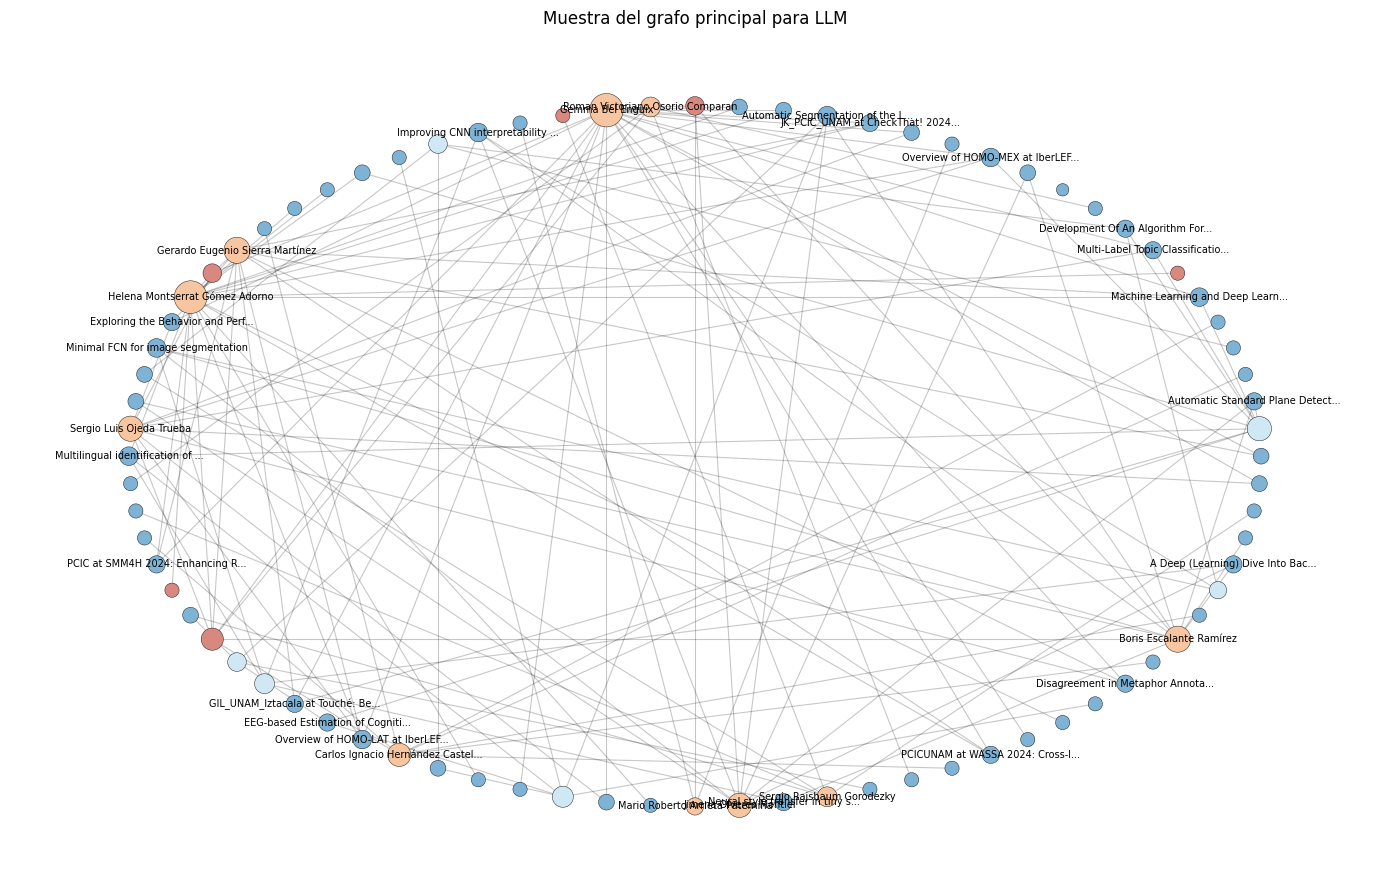

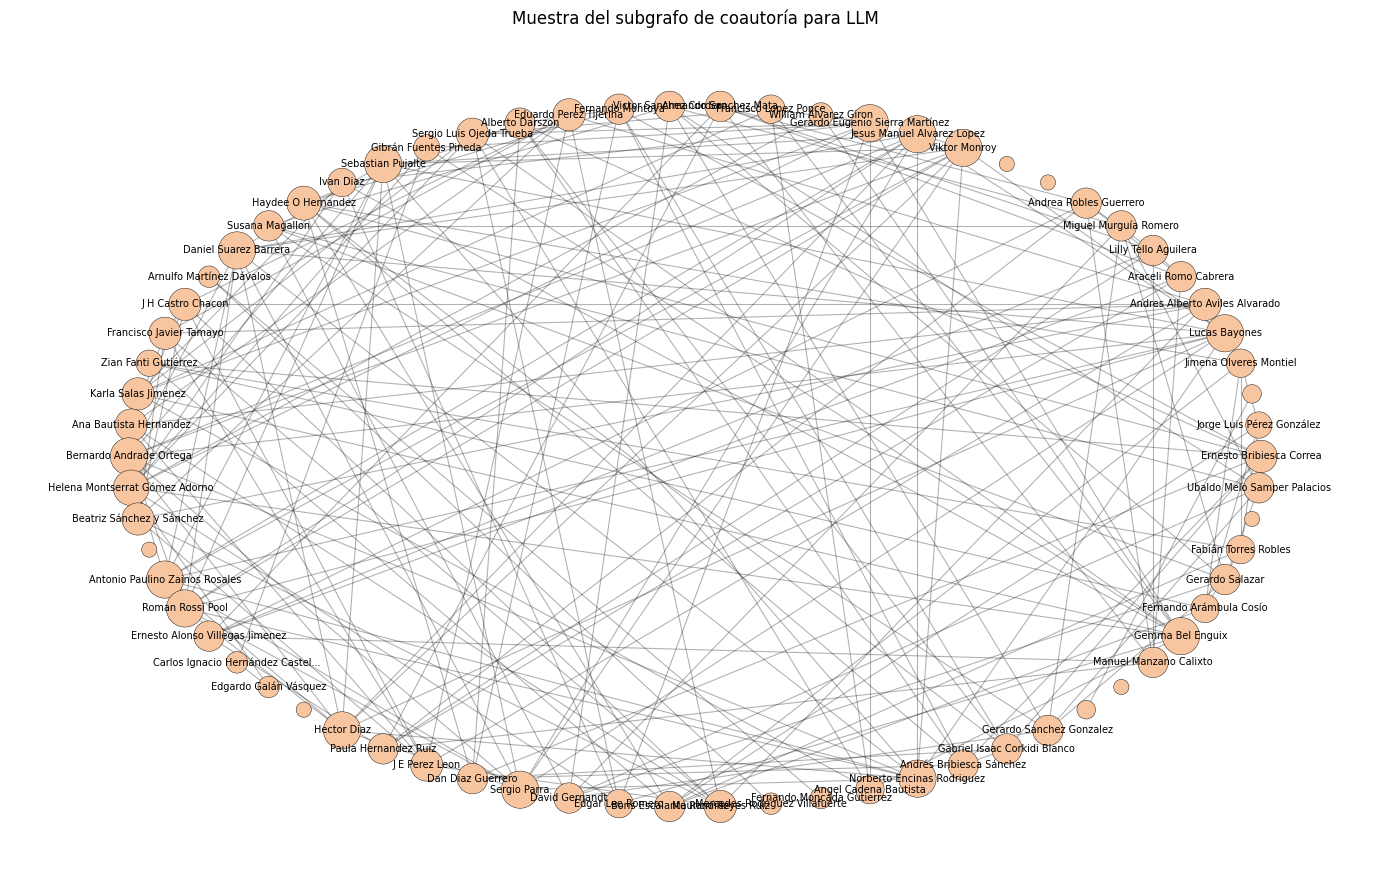

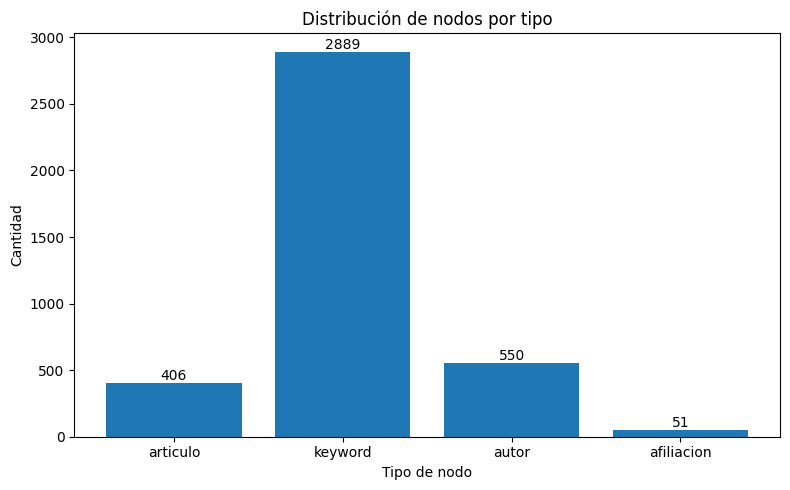

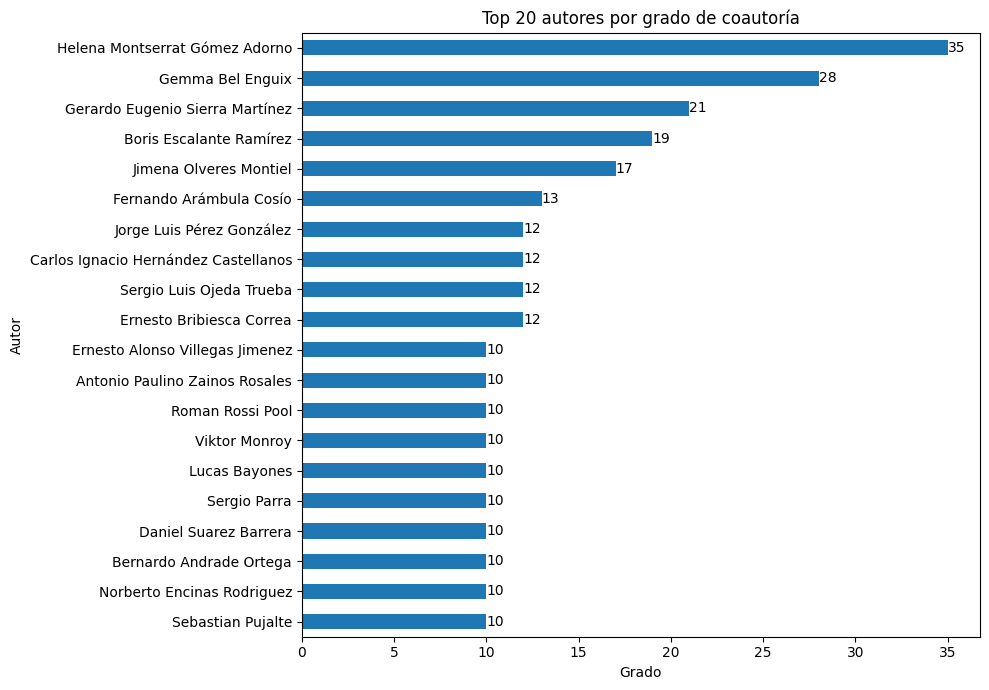

In [ ]:
# ------------------------------------------------------------
# 8. Visualizaciones razonables
# ------------------------------------------------------------
def muestra_grafo_principal(G, max_nodos=80):
    grados = dict(G.degree())
    articulos = [n for n, d in G.nodes(data=True) if d.get("tipo") == "articulo"]
    autores = [n for n, d in G.nodes(data=True) if d.get("tipo") == "autor"]

    semillas = sorted(autores, key=lambda n: grados[n], reverse=True)[:10]
    semillas += sorted(articulos, key=lambda n: grados[n], reverse=True)[:10]

    nodos = set(semillas)
    for n in semillas:
        nodos.update(G.neighbors(n))

    if len(nodos) > max_nodos:
        nodos = set(sorted(nodos, key=lambda n: grados[n], reverse=True)[:max_nodos])
    return G.subgraph(nodos).copy()


def muestra_subgrafo(G_sub, max_nodos=70):
    grados = dict(G_sub.degree())
    nodos = sorted(G_sub.nodes(), key=lambda n: grados[n], reverse=True)[:max_nodos]
    return G_sub.subgraph(nodos).copy()


def dibujar_grafo_principal(G_muestra):
    colores = {
        "articulo": "#7fb3d5",
        "autor": "#f7c59f",
        "keyword": "#cfe8f3",
        "afiliacion": "#d98880",
    }
    plt.figure(figsize=(14, 9))
    pos = nx.circular_layout(G_muestra)
    node_colors = [colores.get(G_muestra.nodes[n].get("tipo"), "#dddddd") for n in G_muestra.nodes()]
    node_sizes = [80 + 25 * G_muestra.degree(n) for n in G_muestra.nodes()]
    labels = {
        n: etiqueta_corta(G_muestra.nodes[n].get("nombre", n))
        for n in G_muestra.nodes()
        if G_muestra.nodes[n].get("tipo") in {"autor", "articulo"} and G_muestra.degree(n) >= 3
    }
    nx.draw_networkx_edges(G_muestra, pos, alpha=0.22, width=0.8)
    nx.draw_networkx_nodes(G_muestra, pos, node_color=node_colors, node_size=node_sizes, edgecolors="black", linewidths=0.3)
    nx.draw_networkx_labels(G_muestra, pos, labels=labels, font_size=7)
    plt.title("Muestra del grafo principal para LLM")
    plt.axis("off")
    guardar_figura("BD_UNAM_Graph_LLM_vista_muestra.png")


def dibujar_subgrafo(G_muestra):
    plt.figure(figsize=(14, 9))
    pos = nx.circular_layout(G_muestra)
    node_sizes = [120 + 60 * G_muestra.degree(n) for n in G_muestra.nodes()]
    labels = {n: etiqueta_corta(n) for n in G_muestra.nodes() if G_muestra.degree(n) >= 2}
    nx.draw_networkx_edges(G_muestra, pos, alpha=0.3, width=0.8)
    nx.draw_networkx_nodes(G_muestra, pos, node_color="#f7c59f", node_size=node_sizes, edgecolors="black", linewidths=0.3)
    nx.draw_networkx_labels(G_muestra, pos, labels=labels, font_size=7)
    plt.title("Muestra del subgrafo de coautoría para LLM")
    plt.axis("off")
    guardar_figura("BD_UNAM_Sub_Graph_LLM_vista_muestra.png")


def barras_tipos_nodos(G):
    conteo = Counter(nx.get_node_attributes(G, "tipo").values())
    plt.figure(figsize=(8, 5))
    plt.bar(conteo.keys(), conteo.values())
    plt.title("Distribución de nodos por tipo")
    plt.xlabel("Tipo de nodo")
    plt.ylabel("Cantidad")
    for i, v in enumerate(conteo.values()):
        plt.text(i, v, str(v), ha="center", va="bottom")
    guardar_figura("01_distribucion_tipos_nodos_LLM.png")
    return conteo


def barras_top_autores(G_sub):
    grados = pd.Series(dict(G_sub.degree())).sort_values(ascending=False).head(20)
    plt.figure(figsize=(10, 7))
    grados.sort_values().plot(kind="barh")
    plt.title("Top 20 autores por grado de coautoría")
    plt.xlabel("Grado")
    plt.ylabel("Autor")
    for i, v in enumerate(grados.sort_values().values):
        plt.text(v, i, str(v), va="center", ha="left")
    guardar_figura("02_top_autores_grado_coautoria_LLM.png")


G_muestra = muestra_grafo_principal(G)
G_sub_muestra = muestra_subgrafo(G_sub)

dibujar_grafo_principal(G_muestra)
dibujar_subgrafo(G_sub_muestra)
conteo_tipos = barras_tipos_nodos(G)
barras_top_autores(G_sub)

In [ ]:
# ------------------------------------------------------------
# 9. Resumen
# ------------------------------------------------------------
resumen = {
    "base": {
        "filas": int(len(df)),
        "articulos": int(df["indice"].nunique()),
        "autores": int(df["Autor_norm"].nunique()),
    },
    "grafo_principal": {
        "nodos": int(G.number_of_nodes()),
        "aristas": int(G.number_of_edges()),
        "nodos_por_tipo": dict(conteo_tipos),
    },
    "subgrafo_coautoria": {
        "nodos": int(G_sub.number_of_nodes()),
        "aristas": int(G_sub.number_of_edges()),
        "componentes_conexas": int(nx.number_connected_components(G_sub)) if G_sub.number_of_nodes() else 0,
        "componente_mayor": int(max((len(c) for c in nx.connected_components(G_sub)), default=0)),
    },
}

with open(CARPETA_SALIDA / "resumen_grafos_LLM.json", "w", encoding="utf-8") as f:
    json.dump(resumen, f, ensure_ascii=False, indent=2)

print("\nResumen")
print(json.dumps(resumen, ensure_ascii=False, indent=2))


Resumen
{
  "base": {
    "filas": 905,
    "articulos": 406,
    "autores": 550
  },
  "grafo_principal": {
    "nodos": 3896,
    "aristas": 5078,
    "nodos_por_tipo": {
      "articulo": 406,
      "keyword": 2889,
      "autor": 550,
      "afiliacion": 51
    }
  },
  "subgrafo_coautoria": {
    "nodos": 550,
    "aristas": 827,
    "componentes_conexas": 173,
    "componente_mayor": 60
  }
}
